# TESSERA pixel embeddings from Sentinel-1/2 via openEO

This notebook loads Sentinel-2 L2A and Sentinel-1 GRD (ascending + descending) through openEO, merges them into a single datacube, and runs the [TESSERA v2 "student"](https://github.com/ucam-eo/tessera) encoder (vendored PyTorch code) as a UDF to produce a 128-band pixel embedding. See [README.md](./README.md) for background and caveats.

## Why geospatial embeddings?

Raw satellite time series are hard to work with directly: hundreds of noisy, cloud-gappy, multi-sensor observations per pixel per year, in units (reflectance, backscatter) that aren't directly comparable across sensors. A pixel *embedding* like TESSERA collapses that whole per-pixel time series into a single dense vector (here, 128 floats) that summarizes the pixel's land-cover/land-use signature for the period. Instead of hand-engineering spectral indices or training a bespoke deep model per task, you can plug these embeddings straight into a lightweight downstream model (e.g. a random forest or shallow classifier) for crop-type mapping, land-cover classification, change detection, or similarity search - often with far less labeled data than training from raw imagery.

## Why openEO for this?

Generating embeddings at scale means orchestrating multi-collection loading (S2 + two S1 orbits), cloud masking, temporal alignment, and running a non-trivial ML model per pixel, over potentially huge areas and multi-year time ranges. openEO handles the heavy lifting so this notebook doesn't have to:
- **One API, many datasets**: `load_collection` + `merge_cubes` abstract away the details of pulling Sentinel-1 and Sentinel-2 from the backend and aligning them onto a common grid/time axis.
- **Bring-your-own-model UDFs**: the TESSERA PyTorch model runs as-is inside the backend via `apply_dimension` + `UDF.from_file`, with dependencies (PyTorch) supplied through `udf-dependency-archives`.
- **Scales without code changes**: the exact same script that processes a small demo AOI here can be pointed at a whole country or a multi-year archive by widening `spatial_extent`/`temporal_extent` the backend distributes the computation across its cluster, so you don't need to manage tiling, parallelization, or infrastructure yourself.
- **Batch jobs for production runs**: `execute_batch` (see "Run the batch job" below) hands the whole pipeline off to the backend as an asynchronous, resumable job well suited to the kind of country/continent-scale, multi-year embedding runs TESSERA is designed for.

The UDF needs PyTorch in the sandbox (installed via a `udf-dependency-archives` job option) and downloads a checkpoint by URL at runtime - see the "Build the UDF" and "Run the batch job" cells below.


In [39]:
import openeo
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Connect to the backend

Using the [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/) openEO endpoint, which hosts both Sentinel-1 and Sentinel-2 collections.

In [40]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Define a small AOI and a one-year temporal extent

Keep the AOI small for a quick/cheap demo run - TESSERA embeddings are normally computed per calendar year.

In [41]:
spatial_extent = {
    "west": 4.5600,
    "south": 43.61,
    "east": 4.69,
    "north": 43.70,
    "crs": 4326,
}

temporal_extent = ["2025-01-01", "2025-12-31"]

## Load Sentinel-2 and both Sentinel-1 orbits

S1 ascending/descending are loaded as separate cubes (filtered via `sat:orbit_state`) and their bands renamed. S2 includes SCL, and cloud masking is performed inside the UDF after source-specific date pruning.

This keeps the process graph backend-compatible (no temporal resampling requirement) and lets the UDF remove merge-introduced union-date NaNs before applying cloud masking NaNs.


In [42]:
# S2 preprocessing
s2_bands = ["B04", "B02", "B03", "B08", "B8A", "B05", "B06", "B07", "B11", "B12", "SCL"]
s2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=s2_bands,
    max_cloud_cover=50,
)

# S1 preprocessing
# Tessera trained on MPC sentinel-1-rtc gamma0 RTC. Here we use sigma0-ellipsoid as the CDSE equivalent.
# Then convert linear backscatter -> Tessera scaled dB:
#   scaled = clip((20 * log10(x) + 50) * 200, 0, 32767)
def _to_tessera_scaled_db(x):
    return ((20 * x.log(base=10) + 50) * 200).clip(min=0, max=32767)


s1_asc = connection.load_collection(
    "SENTINEL1_GRD",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["VV", "VH"],
    properties={"sat:orbit_state": lambda v: v == "ASCENDING"},
)
s1_asc = s1_asc.sar_backscatter()
s1_asc = s1_asc.apply(_to_tessera_scaled_db)
s1_asc = s1_asc.rename_labels(dimension="bands", target=["VV_ASC", "VH_ASC"])
s1_asc = s1_asc.resample_cube_spatial(s2_cube, 'cubic')

s1_desc = connection.load_collection(
    "SENTINEL1_GRD",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["VV", "VH"],
    properties={"sat:orbit_state": lambda v: v == "DESCENDING"},
)
s1_desc = s1_desc.sar_backscatter()
s1_desc = s1_desc.apply(_to_tessera_scaled_db)
s1_desc = s1_desc.rename_labels(dimension="bands", target=["VV_DESC", "VH_DESC"])
s1_desc = s1_desc.resample_cube_spatial(s2_cube, 'cubic')


merged = s2_cube.merge_cubes(s1_asc).merge_cubes(s1_desc)


## Build the UDF

Replace `WEIGHTS_URL` with a direct URL to a TESSERA v2 student checkpoint (a `student_*.pt`
file), e.g. one of the `geotessera/TESSERA-V-2.0-2B-*` repos on the Hugging Face Hub:
`https://huggingface.co/geotessera/TESSERA-V-2.0-2B-N/resolve/main/ckpt/student_nano.pt`.
It must be publicly reachable over HTTPS - the UDF downloads it directly with `torch.load`.

In [43]:
WEIGHTS_URL = "https://huggingface.co/geotessera/TESSERA-V-2.0-2B-N/resolve/main/ckpt/student_nano.pt"  # TODO: pick a checkpoint

udf = openeo.UDF.from_file("udf_tessera_embedding.py", context={"weights_url": WEIGHTS_URL})
embedding_cube = merged.apply_dimension(process=udf, dimension="t", target_dimension="bands")

embedding_cube = embedding_cube.save_result(format="NetCDF")

## Run the batch job

The UDF uses real PyTorch (vendored from `tessera_infer_v2/student`), so torch must be installed
into the UDF sandbox via a `udf-dependency-archives` job option. The checkpoint itself is
downloaded by the UDF at runtime, via the `weights_url` passed in `context` above.

This is also the step where scaling up happens for free: `execute_batch` submits the whole
pipeline (load, mask, merge, embed) to the backend as an asynchronous job. Growing the AOI to a
full country or the temporal extent to several years doesn't require restructuring this notebook -
only `spatial_extent`/`temporal_extent` and the `job_options` memory/parallelism settings need
adjusting; the backend takes care of tiling and distributing the work across its cluster.


In [44]:
job_options = {
    'driver-memory': '3g', 'executor-memory': '3g', 'executor-memoryOverhead': '3g', 'python-memory': '6g', 'soft-errors': 0.1,
    "udf-dependency-archives": [
        "https://s3.waw3-1.cloudferro.com/project_dependencies/torch_deps_python311.zip#feature_deps",
    ],
}

job = embedding_cube.execute_batch(
    "results/tessera_embedding.nc",
    title="TESSERA v2 embedding",
    job_options=job_options,
)

0:00:00 Job 'j-2609100716094733a9c1db7ad70560a3': send 'start'
0:00:03 Job 'j-2609100716094733a9c1db7ad70560a3': created (progress 0%)
0:00:08 Job 'j-2609100716094733a9c1db7ad70560a3': queued (progress 0%)
0:00:14 Job 'j-2609100716094733a9c1db7ad70560a3': queued (progress 0%)
0:00:22 Job 'j-2609100716094733a9c1db7ad70560a3': queued (progress 0%)
0:00:33 Job 'j-2609100716094733a9c1db7ad70560a3': queued (progress 0%)
0:00:45 Job 'j-2609100716094733a9c1db7ad70560a3': queued (progress 0%)
0:01:02 Job 'j-2609100716094733a9c1db7ad70560a3': queued (progress 0%)
0:01:22 Job 'j-2609100716094733a9c1db7ad70560a3': running (progress N/A)
0:01:46 Job 'j-2609100716094733a9c1db7ad70560a3': running (progress N/A)
0:02:16 Job 'j-2609100716094733a9c1db7ad70560a3': running (progress N/A)
0:02:54 Job 'j-2609100716094733a9c1db7ad70560a3': running (progress N/A)
0:03:41 Job 'j-2609100716094733a9c1db7ad70560a3': running (progress N/A)
0:04:39 Job 'j-2609100716094733a9c1db7ad70560a3': running (progress N/A)
0

## Visualize the embedding (PCA to RGB)

The 128-d embedding isn't directly viewable, so reduce it to 3 principal components for a quick visual sanity check (same approach as [../DimensionalityReduction](../DimensionalityReduction)). Distinct colors/textures below correspond to different land-cover/land-use patterns the embedding has picked up - the same signal a downstream classifier would exploit.

(np.float64(-0.5), np.float64(1067.5), np.float64(1020.5), np.float64(-0.5))

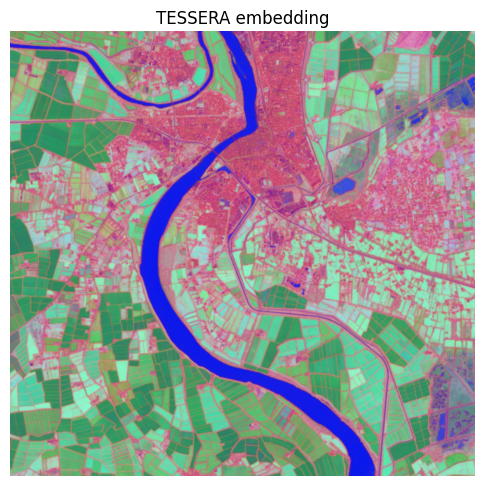

In [46]:
output = xr.open_dataset("results/tessera_embedding.nc")
output = output.drop_vars('crs')

arr = output.to_array(dim="bands").squeeze()  # (bands, y, x)

flat = arr.values.reshape(arr.shape[0], -1).T  # (pixels, bands)
flat = flat - flat.mean(axis=0, keepdims=True)
u, s, vt = np.linalg.svd(flat, full_matrices=False)
rgb = (u[:, :3] * s[:3]).reshape(arr.shape[1], arr.shape[2], 3)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title("TESSERA embedding")
plt.axis("off")

## Conclusion

This notebook turned raw, multi-sensor Sentinel-1/2 time series into a compact 128-band TESSERA embedding per pixel, using openEO to handle the data loading, cloud masking, and multi-collection alignment, and a UDF to run the pretrained PyTorch encoder directly inside the backend. The resulting embedding is a general-purpose representation of each pixel's land-cover/land-use signature - ready to feed into lightweight downstream models (classification, change detection, similarity search) instead of raw imagery.

Because the whole pipeline is expressed as an openEO process graph, scaling from this small demo AOI to a full country or a multi-year archive is just a matter of widening `spatial_extent`/`temporal_extent` and submitting via `execute_batch`: no changes to the loading, masking, or UDF logic are needed. See [README.md](./README.md) for further background, caveats, and pointers to the original TESSERA project.
